In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 데이터 적재와 분할
cancer = load_breast_cancer()
x_train, x_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

# 훈련 데이터의 최솟값, 최댓값을 계산합니다
scaler = MinMaxScaler().fit(x_train)

In [4]:
# 훈련 데이터의 스케일을 조정합니다
x_train_scaled = scaler.transform(x_train)

svm = SVC()
# 스케일 조정된 훈련데이터에 SVM을 학습시킵니다
svm.fit(x_train_scaled, y_train)
# 테스트 데이터의 스케일을 조정하고 점수를 계산합니다
x_test_scaled = scaler.transform(x_test)
print('test score: {:.2f}'.format(svm.score(x_test_scaled, y_test)))

test score: 0.97


In [5]:
from sklearn.model_selection import GridSearchCV
# 이 코드는 예를 위한 것입니다 실제로 사용하지 마세요
param_grid = {'C':[0.001,0.01,0.1,1,10,100],
              'gamma':[0.001,0.01,0.1,1,10,100]}
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=5)
grid.fit(x_train_scaled, y_train)
print('best cross validation accuracy: {:.2f}'.format(grid.best_score_))
print('test score: {:.2f}'.format(grid.score(x_test_scaled, y_test)))
print('best parameter:', grid.best_params_)

best cross validation accuracy: 0.98
test score: 0.97
best parameter: {'C': 1, 'gamma': 1}


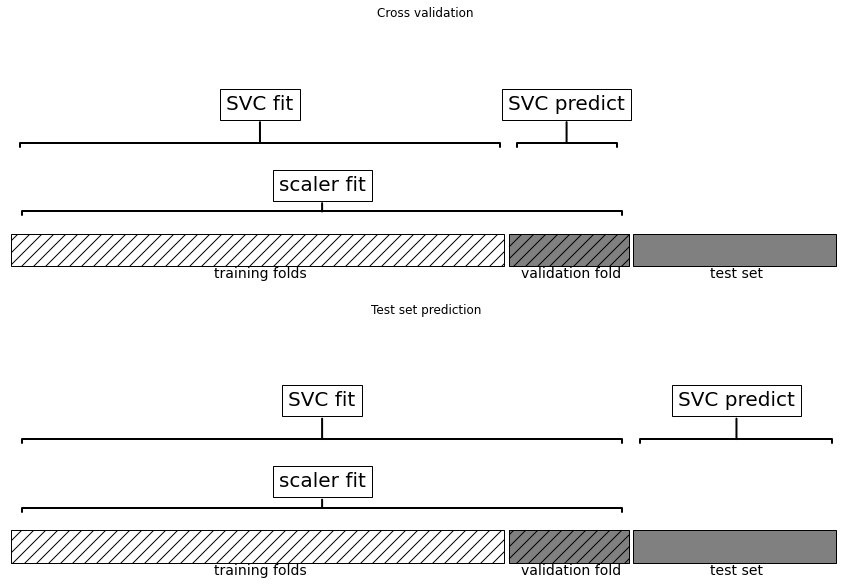

In [6]:
mglearn.plots.plot_improper_processing()

In [7]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([('scaler', MinMaxScaler()), ('svm', SVC())])

In [8]:
pipe.fit(x_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()), ('svm', SVC())])

In [9]:
print('test score: {:.2f}'.format(pipe.score(x_test, y_test)))

test score: 0.97


In [10]:
param_grid = {'svm__C':[0.001,0.01,0.1,1,10,100],
              'svm__gamma':[0.001,0.01,0.1,1,10,100]}

In [11]:
grid = GridSearchCV(pipe, param_grid=param_grid, cv=5)
grid.fit(x_train, y_train)
print('best score: {:.2f}'.format(grid.best_score_))
print('test set score: {:.2f}'.format(grid.score(x_test, y_test)))
print('best parameter:', grid.best_params_)

best score: 0.98
test set score: 0.97
best parameter: {'svm__C': 1, 'svm__gamma': 1}


In [13]:
rnd = np.random.RandomState(seed=0)
x = rnd.normal(size=(100, 10000))
y = rnd.normal(size=(100,))

In [14]:
from sklearn.feature_selection import SelectPercentile, f_regression

select = SelectPercentile(score_func=f_regression, percentile=5).fit(x, y)
x_selected = select.transform(x)
print('x_selected.shape:', x_selected.shape)

x_selected.shape: (100, 500)


In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
print('cross score(ridge): {:.2f}'.format(np.mean(cross_val_score(Ridge(), x_selected, y, cv=5))))

cross score(ridge): 0.91


In [16]:
pipe = Pipeline([('select', SelectPercentile(score_func=f_regression, percentile=5)), ('ridge', Ridge())])
print('cross score(pipe): {:.2f}'.format(np.mean(cross_val_score(pipe, x, y, cv=5))))

cross score(pipe): -0.25


In [17]:
def fit(self, x, y):
    x_transformed = x
    for name, estimator in self.steps[:-1]:
        # 마지막 단계를 빼고 fit과 transfrom을 반복합니다
        x_transformed = estimator.fit_transform(x_transformed, y)
    # 마지막 단계 fit을 호출합니다
    self.steps[-1][1].fit(x_transformed, y)
    return self

In [18]:
def predict(self, x):
    x_transformed = x
    for step in self.steps[:-1]:
        # 마지막 단계를 빼고 transform을 반복합니다
        x_transformed = step[1].transform(x_transformed)
    # 마지막 단계 predict을 호출합니다
    return self.steps[-1][1].predict(x_transformed)

In [19]:
from sklearn import set_config

set_config(display='diagram')
pipe

Pipeline(steps=[('select',
                 SelectPercentile(percentile=5,
                                  score_func=<function f_regression at 0x0000019349D49AF0>)),
                ('ridge', Ridge())])

In [20]:
from sklearn.pipeline import make_pipeline
# 표준적인 방법
pipe_long = Pipeline([('scaler', MinMaxScaler()), ('svm', SVC(C=100))])
# 간소화된 방법
pipe_short = make_pipeline(MinMaxScaler(), SVC(C=100))

In [21]:
print('pipeline step:\n', pipe_short.steps)

pipeline step:
 [('minmaxscaler', MinMaxScaler()), ('svc', SVC(C=100))]


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipe = make_pipeline(StandardScaler(), PCA(n_components=2), StandardScaler())
print('pipeline step:\n', pipe.steps)

pipeline step:
 [('standardscaler-1', StandardScaler()), ('pca', PCA(n_components=2)), ('standardscaler-2', StandardScaler())]


In [24]:
# cancer 데이터셋에 앞서 만든 파이프라인을 적용합니다
pipe.fit(cancer.data)
# 'pca' 단계의 두 개 주성분을 추출합니다
components = pipe.named_steps['pca'].components_
print('components.shape:', components.shape)

components.shape: (2, 30)


In [25]:
from sklearn.linear_model import LogisticRegression
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

In [26]:
param_grid = {'logisticregression__C':[0.01,0.1,1,10,100]}

In [27]:
x_train, x_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=4)
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100]})

In [28]:
print('best model:\n', grid.best_estimator_)

best model:
 Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(C=1, max_iter=1000))])


In [29]:
print('logi reg step:\n', grid.best_estimator_.named_steps['logisticregression'])

logi reg step:
 LogisticRegression(C=1, max_iter=1000)


In [30]:
print('logi reg coef:\n', grid.best_estimator_.named_steps['logisticregression'].coef_)

logi reg coef:
 [[-0.43570655 -0.34266946 -0.40809443 -0.5344574  -0.14971847  0.61034122
  -0.72634347 -0.78538827  0.03886087  0.27497198 -1.29780109  0.04926005
  -0.67336941 -0.93447426 -0.13939555  0.45032641 -0.13009864 -0.10144273
   0.43432027  0.71596578 -1.09068862 -1.09463976 -0.85183755 -1.06406198
  -0.74316099  0.07252425 -0.82323903 -0.65321239 -0.64379499 -0.42026013]]


In [32]:
from sklearn.datasets import load_boston
boston = load_boston()
x_train, x_test, y_train, y_test = train_test_split(boston.data, boston.target, random_state=0)

from sklearn.preprocessing import PolynomialFeatures
pipe = make_pipeline(StandardScaler(), PolynomialFeatures(), Ridge())

In [34]:
param_grid = {'polynomialfeatures__degree':[1,2,3],
              'ridge__alpha':[0.001,0.01,0.1,1,10,100]}

In [35]:
grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'polynomialfeatures__degree': [1, 2, 3],
                         'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

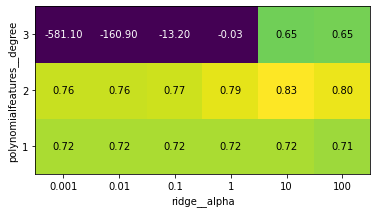

In [37]:
mglearn.tools.heatmap(grid.cv_results_['mean_test_score'].reshape(3,-1), xlabel='ridge__alpha', ylabel='polynomialfeatures__degree',
                      xticklabels=param_grid['ridge__alpha'], yticklabels=param_grid['polynomialfeatures__degree'], vmin=0)

In [38]:
print('best parameter:', grid.best_params_)

best parameter: {'polynomialfeatures__degree': 2, 'ridge__alpha': 10}


In [39]:
print('test set score: {:.2f}'.format(grid.score(x_test, y_test)))

test set score: 0.77


In [40]:
param_grid = {'ridge__alpha':[0.001,0.01,0.1,1,10,100]}
pipe = make_pipeline(StandardScaler(), Ridge())
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(x_train, y_train)
print('no poly score: {:.2f}'.format(grid.score(x_test, y_test)))

no poly score: 0.63


In [41]:
pipe = Pipeline([('preprocessing', StandardScaler()), ('classifier', SVC())])

In [42]:
from sklearn.ensemble import RandomForestClassifier

param_grid = [
    {'classifier':[SVC()], 'preprocessing':[StandardScaler()],
     'classifier__gamma':[0.001,0.01,0.1,1,10,100],
     'classifier__C':[0.001,0.01,0.1,1,10,100]},
    {'classifier':[RandomForestClassifier(n_estimators=100)],
     'preprocessing':[None], 'classifier__max_features':[1,2,3]}
]

In [43]:
x_train, x_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(x_train, y_train)
print('best parameter:\n{}\n'.format(grid.best_params_))
print('best cross score: {:.2f}'.format(grid.best_score_))
print('test set score: {:.2f}'.format(grid.score(x_test, y_test)))

best parameter:
{'classifier': SVC(C=10, gamma=0.01), 'classifier__C': 10, 'classifier__gamma': 0.01, 'preprocessing': StandardScaler()}

best cross score: 0.99
test set score: 0.98


In [44]:
pipe = Pipeline([('preprocessing', StandardScaler()), ('classifier', SVC())], memory='cache_folder')